In [40]:
import pykonal 
from pykonal import solver
import os 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 

import os

from src.fct_DAS_sensitivity import *
from src.fct_ttime_grid import *
from tqdm import tqdm

## Velocity model 
Load a 1D velocity model from .CSV file, crop and smooth it

In [41]:
FILEPATH_VELOCITY = r'C:\Users\liliv\Desktop\codes\DAS_sensitivity copy\Data\Velocity_profile\BHS.csv'
phase = 'Vs' # Name of your column in the CSV file to use
smoothing_window = 4 # smoothing over n consecutive element of the depth range defined in next cell

Set the extent and resolution of the model space.

In [42]:
depths = np.linspace(-2, 10, 40) # range of depth values
latitudes = np.linspace(39.814841, 39.797048, 40) # range of latitude values 
longitudes = np.linspace(-119.017293, -118.991879, 40)# range of longitude values

Load velocity model

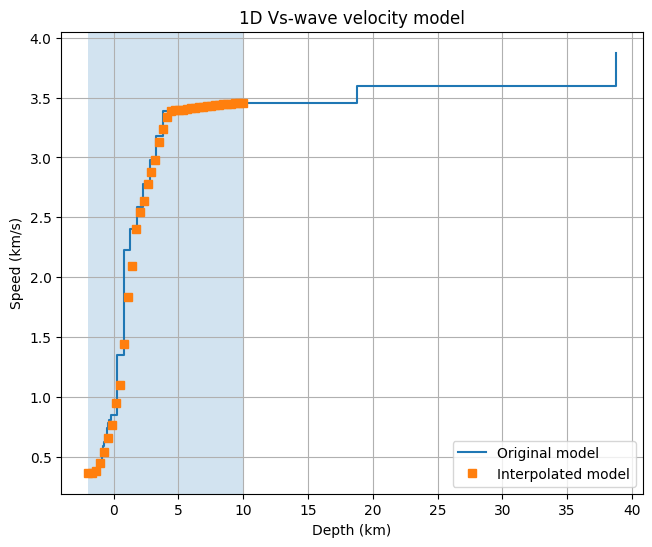

In [43]:
velocity_model = load_velocity_model(
    filepath_velocity=FILEPATH_VELOCITY,
    depths=depths,
    phase=phase,
    smoothing_window=smoothing_window,
    plot = True
)

## Source description 

To define your source you must **locate** it using the class: <br>
* Location(latitude, longitude, depth) # °N, °E, km (sea level = 0, positif going down)

We created 3 classes of source for different applications : <br>
* **Homogeneous** : <br>

e = IsotropicSource(amplitude) <br>
* **Moment tensor** : <br>

e = MomentTensor(xx, yy, zz, xy, xz, yz)  <br>

* **Single force**: <br>

e = SingleForce(N, E, depth) <br><br>
For all these source we only use the far field approximation of the orientation specific amplitude distribution of the energy around the source. 

In [49]:
name = 'SF'
# Locate your source in space 
loc = Location(39.8097, -119.0022, -1.246369) # lat, lon depth

# Describe the energy inside 
e = MomentTensor(1, 1, -2, 0, 0, 0)
#Create the source object 
source = SeismicSource(name, loc, e)



# Wave type to considerate in computation 
wave_type_list = ['P','SV', 'SH']

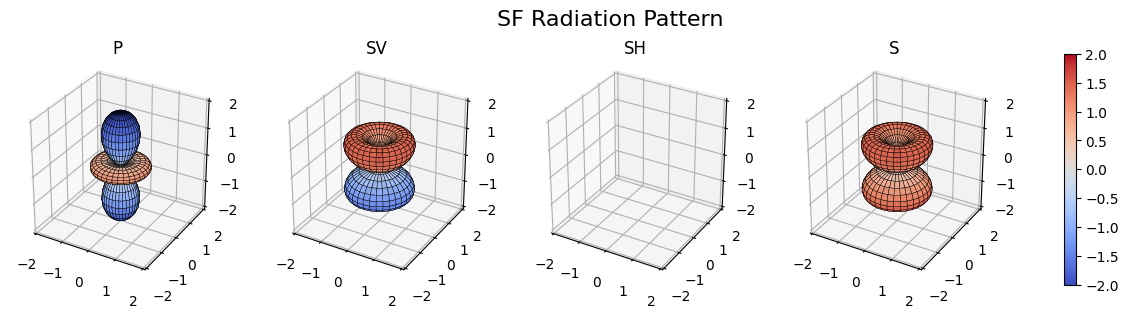

In [50]:
source.plot_radiation_pattern()

## create ttimes grids

In [51]:
ttimes = create_ttitme(source, velocity_model, latitudes, longitudes)

## Load channels informations

Load dataframe

In [52]:
### path to station info ###
station_info_path = r'C:\Users\liliv\Desktop\codes\DAS_sensitivity copy\Data\DAS_arrays\Brady_Hot_springs\BHS_DASH.csv'
station_info = pd.read_csv(station_info_path, sep = ',', index_col =0)
station_info = compute_azimuth_dip(station_info)
print(station_info.head(5))

                lat         lon    Elevation     depth     azimuth       dip
Distance                                                                    
35        39.799373 -119.011287  1246.368571 -1.246369    7.174915 -0.000049
46        39.799471 -119.011303  1246.368571 -1.246369    7.174178 -0.000049
57        39.799569 -119.011319  1246.368571 -1.246369    7.087563 -0.000049
68        39.799666 -119.011335  1246.368571 -1.246369  342.850985 -0.000046
79        39.799754 -119.011300  1246.368571 -1.246369  324.298368 -0.000049


Create fiber object

In [53]:
columns = {
    "latitude": "lat",
    "longitude": "lon",
    "depth": "depth",
    "azimuth": "azimuth",
    "dip": "dip",
}
fiber = Fiber(
    dataframe=station_info,
    columns=columns
)

## Run ray tracing

Create model from travel time grid 

In [54]:
### Initialize the solver once with constant grid settings ###

solver = pykonal.solver.PointSourceSolver(coord_sys="spherical")
# Set up grid properties 
solver.velocity.min_coords = ttimes.attrs['reference_point'] 
solver.velocity.node_intervals = ttimes.attrs['node_intervals']
solver.velocity.npts = ttimes.values.shape  # Ensure shape matches the travel time grid

# Ensure the travel time grid is set correctly in the solver
solver.tt.values = ttimes.transpose('depth', 'latitude', 'longitude').values  # Adjust dimensions if needed


# Create DataFrame to hold results 
result_container = pd.DataFrame()

Set error parameters and minimal noise level

In [55]:
# MC error hestimate
receiver_error = 3.55
source_error = 0.59
MC_sample_number = 100

# Minimum distance (km)
min_distance = 0.1

noise_level = 1e-4

Loop through all channels in fiber

In [56]:
for index, das in tqdm(enumerate(fiber)):

        ################# Ray tracing ################## 
        end = np.array(geo2sph(das.values()).squeeze()) 
        d = distance_3d_km(lat1=das.values()[0], lon1=das.values()[1], depth1_km=das.values()[2],lat2=source.location.values[0], lon2=source.location.values[1], depth2_km=source.location.values[2])
        # 1) if source and receiver to close => take a straight ray 
        if d<= min_distance:
                lats = np.linspace(das.values()[0],source.location.values[0], 200 ) # ° latitude (N)
                lons = np.linspace(das.values()[1],source.location.values[1], 200 ) # ° longitude (E)
                depth = np.linspace (das.values()[2],source.location.values[2], 200) # km of depth
                ray = np.array([lats, lons, depth])
                ray = Ray(geo2sph(ray.T))
        # 2) if source revceiver far enough => use ttime to run ray tracing 
        else:      
                ray_nodes = solver.trace_ray(end)
                # Pykonal returns a ray without the source and receiver node. We add them back in this line 
                # first node is at the DAS and last node at the source
                ray_nodes = np.vstack([np.array(geo2sph(das.values()).squeeze()),ray_nodes, end ])
                ray = Ray(ray_nodes)

        ################# Travel time ####################        
        tt_source = solver.traveltime.value(end)
        # save ttime value
        result_container.loc[str(index), 'ttime'] = tt_source 

        ################### Ray path #####################
        # get ray length in m
        ray_length = ray.length_spherical()*1000 # in m 
        #ray.plot_views()

        ############### Phase sensitivity ################
        az_ray_DAS, dip_ray_DAS = ray.azimuth_and_dip('source', 50) # fliped as model runs in reverse 
        az_ray_source, dip_ray_source = ray.azimuth_and_dip('DAS', 50) # fliped as model runs in reverse 

        for wave_type in wave_type_list :

                # use MC sampling to get error on measure 
                MC_Channel_amplitude = np.zeros(MC_sample_number)

                MC_dip_fibre = np.random.normal(loc=dip_ray_DAS, scale=receiver_error/np.sqrt(2), size=MC_sample_number) 
                MC_ray_azimuth_fibre = np.random.normal(loc=az_ray_DAS, scale=receiver_error/np.sqrt(2), size=MC_sample_number)
                
                MC_azimuth_source = np.random.normal(loc=az_ray_source, scale=source_error/np.sqrt(2), size=MC_sample_number)
                MC_colatitude_source = np.random.normal(loc=dip_ray_source, scale=source_error/np.sqrt(2), size=MC_sample_number)
                
                for MC_sample in range(MC_sample_number):
                
                        if MC_sample != 0:
                        
                                dip_ray_source = MC_colatitude_source[MC_sample]
                                az_ray_source = MC_azimuth_source [MC_sample]
                                
                                az_ray_DAS = MC_ray_azimuth_fibre[MC_sample]
                                dip_ray_DAS = MC_dip_fibre[MC_sample]
                        
                        ### STEP 1) Axial strain for the ray 
                        fiber_sensitivity = das.sensitivity(wave_type, az_ray_DAS, dip_ray_DAS)
                        
                        ### STEP 2) Amplitude from the source mechanism
                        
                        FF_A = source.radiation_amplitude(az_ray_source, dip_ray_source, wave_type)
                        ### step 3) assemple all 

                        phase_sensitivity = (fiber_sensitivity * FF_A) / ray_length

                        if wave_type != 'P':
                                # scale up S wave by 5 because amplitude ratio between S waves and P waves is alpha³ / beta ³
                                phase_sensitivity = phase_sensitivity*5  

                        MC_Channel_amplitude[MC_sample] =  phase_sensitivity          
                                 
                result_container.loc[str(index), str(wave_type)] = np.median(MC_Channel_amplitude)
                result_container.loc[str(index), 'error_'+str(wave_type)] = np.std(MC_Channel_amplitude)
                

                        
                        
#result_container.to_csv(folder_out+'/'+file_name+'.csv')

784it [01:46,  7.36it/s]


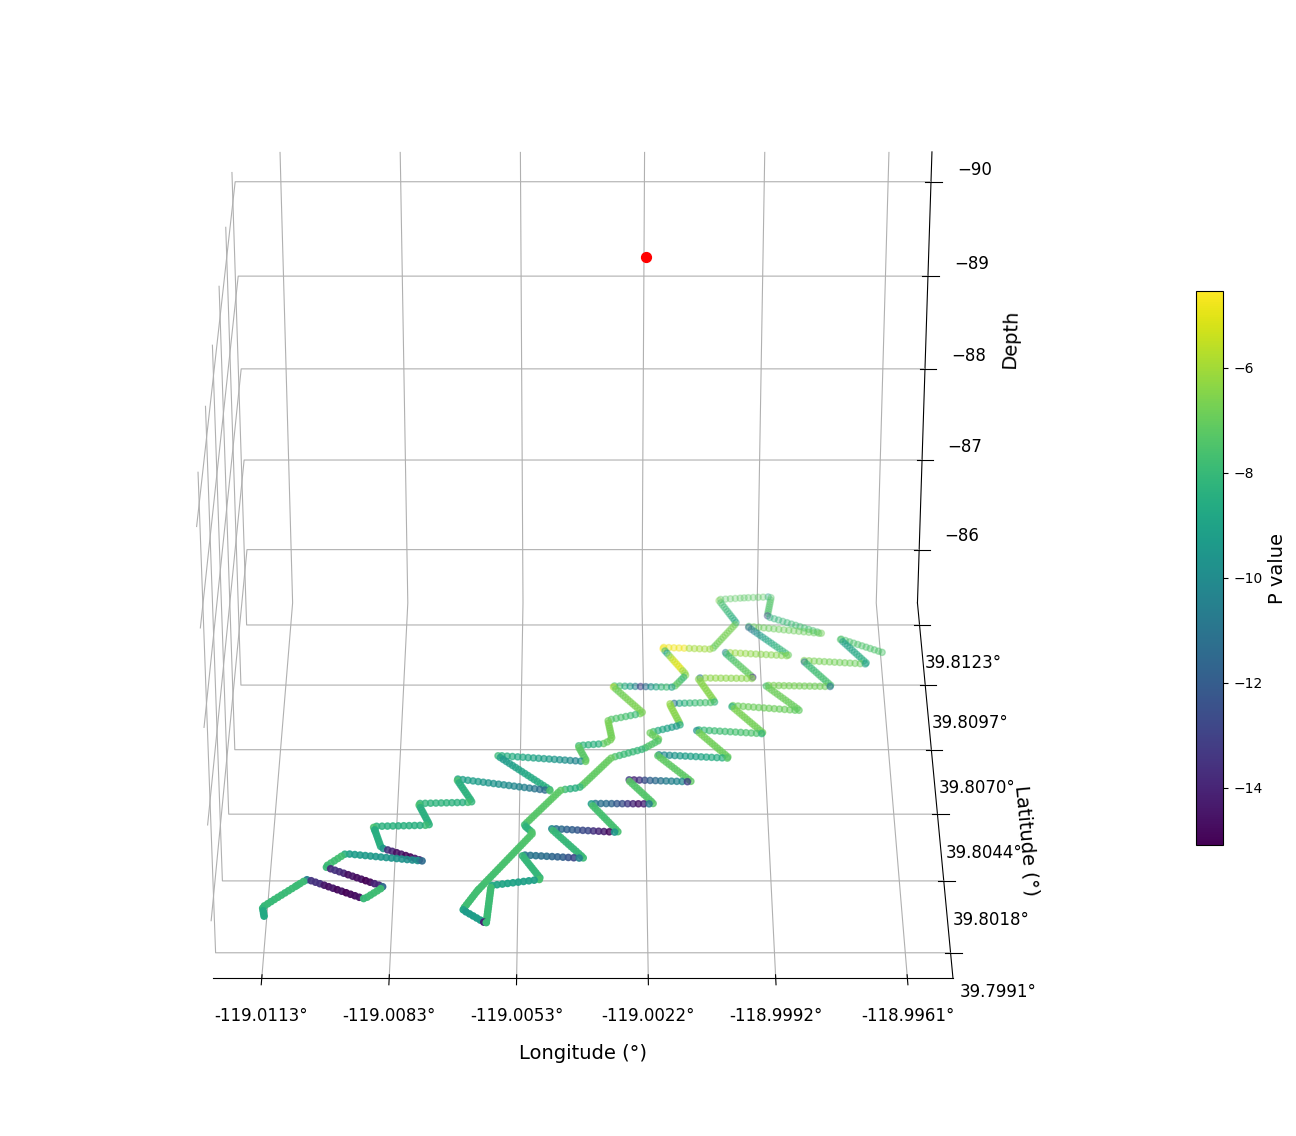

In [57]:
df = station_info
Phase_to_plot = 'P'

fig = plt.figure(figsize=(18, 18))
ax1 = fig.add_subplot(projection='3d')

# Save scatter object
sc = ax1.scatter(
    df['lon'].values,
    df['lat'].values,
    df['depth'].values,
    c=np.log(np.abs(result_container[Phase_to_plot].values)),
    cmap='viridis'
)

# Add colorbar
cbar = plt.colorbar(sc, ax=ax1, pad=0.05, shrink=0.4)
cbar.set_label(f"{Phase_to_plot} value", fontsize=14)

# Axis view & limits
ax1.view_init(elev=30, azim=-90)

# Labels
ax1.set_xlabel('Longitude (°)')
ax1.set_ylabel('Latitude (°)')
ax1.set_zlabel('Depth (km)')

# Custom ticks
lon_min, lon_max = df['lon'].min(), df['lon'].max()
lat_min, lat_max = df['lat'].min(), df['lat'].max()

lon_ticks = np.round(np.linspace(lon_min, lon_max, 6), 4)
lat_ticks = np.round(np.linspace(lat_min, lat_max, 6), 4)

ax1.set_xticks(lon_ticks)
ax1.set_yticks(lat_ticks)
ax1.set_xticklabels([f'{v:.4f}°' for v in lon_ticks])
ax1.set_yticklabels([f'{v:.4f}°' for v in lat_ticks])

ax1.tick_params(axis='x', labelsize=12, pad=6)
ax1.tick_params(axis='y', labelsize=12, pad=20)
ax1.tick_params(axis='z', labelsize=12, pad=20)

ax1.set_xlabel('Longitude (°)', fontsize=14, labelpad=15)
ax1.set_ylabel('Latitude (°)', fontsize=14, labelpad=35)
ax1.set_zlabel('Depth', fontsize=14, labelpad=35)

ax1.scatter(
    source.location.values[1],
    source.location.values[0],
    source.location.values[2],
    s=50,
    c='r'
)

# Optional: transparent panes
ax1.xaxis.pane.fill = False
ax1.yaxis.pane.fill = False
ax1.zaxis.pane.fill = False

ax1.xaxis.pane.set_edgecolor('w')
ax1.yaxis.pane.set_edgecolor('w')
ax1.zaxis.pane.set_edgecolor('w')

ax1.invert_zaxis()

plt.show()

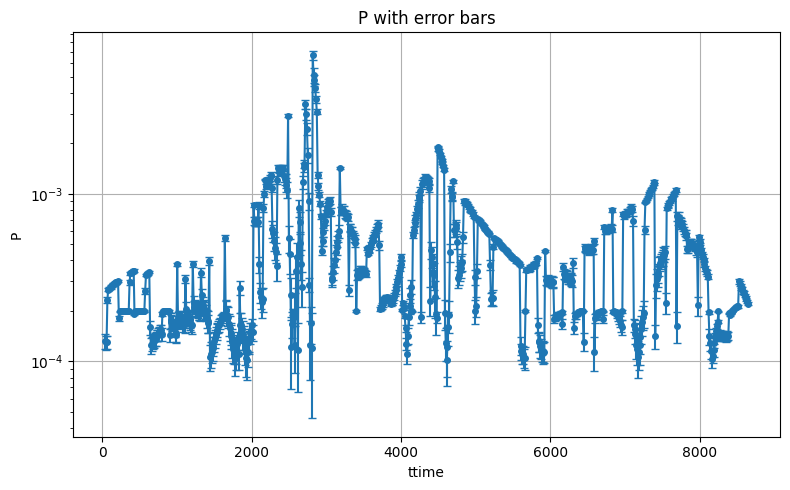

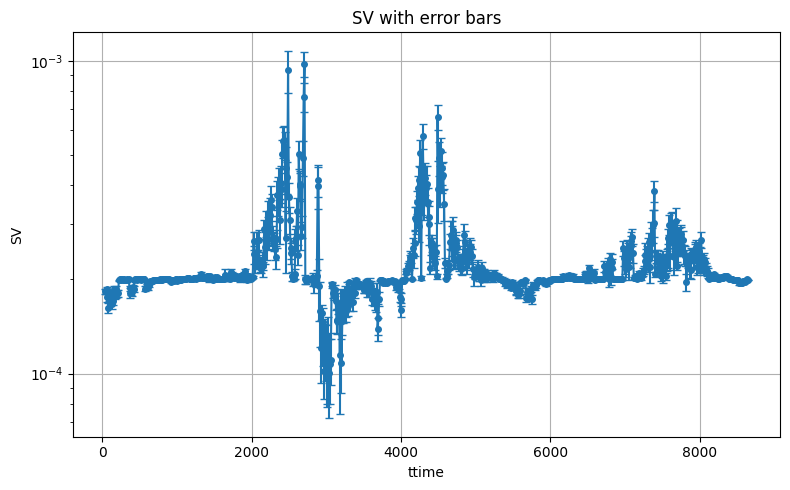

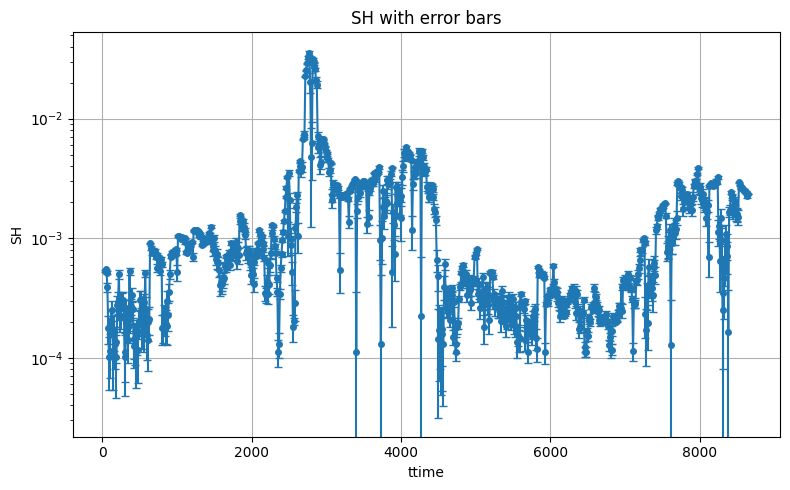

In [27]:

# Columns to plot: (value, error)
pairs = [
    ("P", "error_P"),
    ("SV", "error_SV"),
    ("SH", "error_SH"),
]

# x-axis
x = df.index

for value_col, error_col in pairs:
    plt.figure(figsize=(8, 5))

    plt.errorbar(
        x,
        np.abs(result_container[value_col])+1e-4,
        yerr=result_container[error_col],
        fmt="o",
        markersize=4,
        capsize=3,
        linestyle="-"
    )

    plt.xlabel("ttime")
    plt.ylabel(value_col)
    plt.title(f"{value_col} with error bars")
    plt.grid(True)
    plt.yscale('log')

    plt.tight_layout()
    plt.show()